In [ ]:
import pandas as pd


In [ ]:
titanic_df=pd.read_csv("F:\github\Data preprocessing\Titanic_data.csv")

<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_12704\3966130584.py:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  titanic_df=pd.read_csv("F:\github\Data preprocessing\Titanic_data.csv")


In [ ]:
titanic_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


Rename columns


In [ ]:
titanic_df.rename(columns={"Pclass":"PStatus","Sex":"Gender"}, inplace=True)

In [ ]:
titanic_df.reset_index(drop=True)

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
titanic_df.rename(index={0:"Zero",2:"Two"}).head()

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Zero,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
Two,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'PStatus', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

***Outlier Handling***

<Axes: >

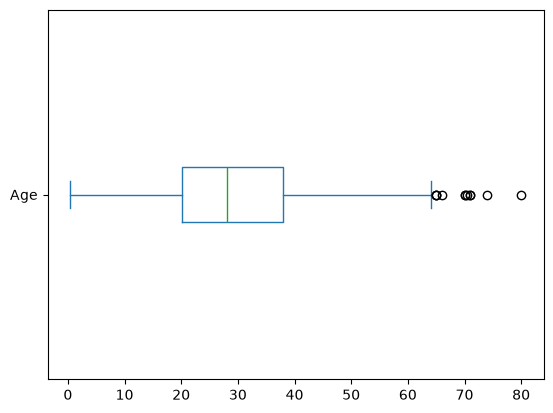

In [ ]:
titanic_df.Age.plot(kind="box", vert=False)

In [ ]:
Q1=titanic_df.Age.quantile(q=0.25)
Q3=titanic_df.Age.quantile(q=0.75)
IQR=Q3-Q1
maximum=Q3+(1.5*IQR)
minimum=Q3-(1.5*IQR)

In [ ]:
maximum

np.float64(64.8125)

In [ ]:
minimum

np.float64(11.1875)

In [ ]:
#filtering outliers
titanic_df[(titanic_df.Age>maximum) |(titanic_df.Age<minimum)].shape

(79, 12)

In [ ]:
titanic_df_Ageoutlier=titanic_df[(titanic_df.Age<=maximum) |(titanic_df.Age>=minimum)]

In [ ]:
titanic_df_Ageoutlier.head()

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: >

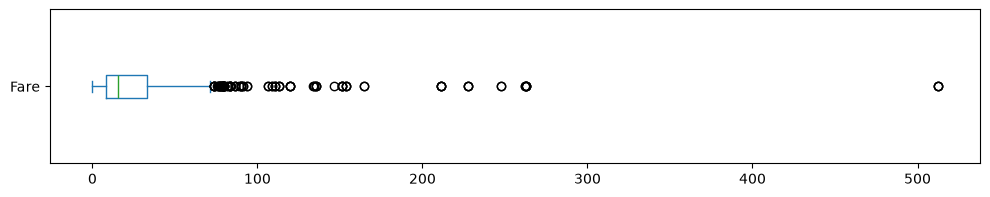

In [ ]:
#fare
titanic_df_Ageoutlier.Fare.plot(kind="box",vert=False,figsize=(12,2))

In [ ]:
Q1=titanic_df.Fare.quantile(q=0.4)
Q3=titanic_df.Fare.quantile(q=0.75)
IQR=Q3-Q1
maximum=Q3+(1.5*IQR)
minimum=Q3-(1.5*IQR)
print(minimum,maximum)

0.25 61.75


In [ ]:
titanic_df_FareOutlier=titanic_df[(titanic_df.Fare<=maximum) | (titanic_df.Fare>=minimum)]

In [ ]:
titanic_df_FareOutlier.head()

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: >

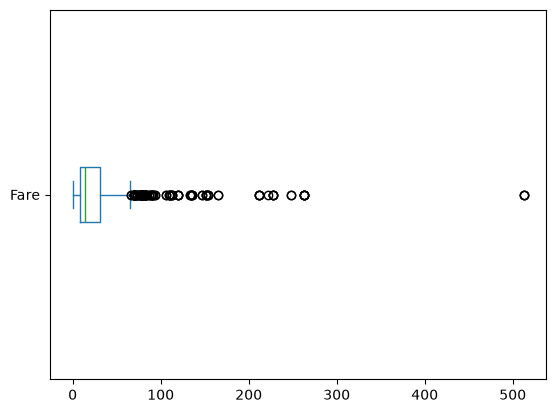

In [ ]:
titanic_df_FareOutlier.Fare.plot(kind="box",vert=False)

***Z Score***
define how far data is from mean

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
x=np.linspace(-5,5,2000)

In [ ]:
y=stats.norm.pdf(x)

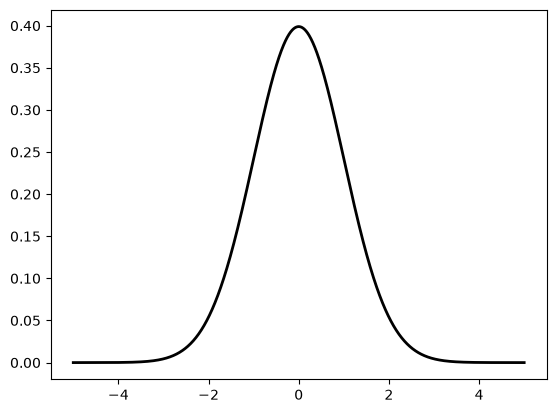

In [ ]:
plt.plot(x,y,"black",lw=2,label="Standard Normal Distribution")

In [ ]:
#Calcluate and  Interpreting Z-Score
sample=list(range(150,200,4))
sample

[150, 154, 158, 162, 166, 170, 174, 178, 182, 186, 190, 194, 198]

In [ ]:
sample_mean=np.mean(sample)

In [ ]:
sample_std=np.std(sample,ddof=1)

In [ ]:
sample_mean,sample_std

(np.float64(174.0), np.float64(15.57776192739723))

In [ ]:
z_score=(sample-sample_mean)/sample_std

In [ ]:
for i,z in enumerate(z_score):
    print(f"Data point{i}:{sample[i]} has z-score={z:3f}")

Data point0:150 has z-score=-1.540658
Data point1:154 has z-score=-1.283881
Data point2:158 has z-score=-1.027105
Data point3:162 has z-score=-0.770329
Data point4:166 has z-score=-0.513553
Data point5:170 has z-score=-0.256776
Data point6:174 has z-score=0.000000
Data point7:178 has z-score=0.256776
Data point8:182 has z-score=0.513553
Data point9:186 has z-score=0.770329
Data point10:190 has z-score=1.027105
Data point11:194 has z-score=1.283881
Data point12:198 has z-score=1.540658


In [ ]:
z_score=abs(titanic_df_Ageoutlier.Age-titanic_df_Ageoutlier.Age.mean())/titanic_df_Ageoutlier.Age.std()

In [ ]:
titanic_df_Ageoutlier[z_score>2.6]

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [ ]:
#save to csv
titanic_df_Ageoutlier.to_csv("titanic_df_Ageoutlier.csv")